In [1]:
import joblib
from analysis_utils import *

# Görselleştirme Ayarları
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/student_dataset_10000_rows.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

1. Veri Yüklendi. Boyut: (10000, 8)


In [3]:
# --- 2. Genel Yapı, Tipler ve Eksik Veri Analizi ---
check_general_structure(df)

=== Veri Tipleri ve Non-Null Bilgisi ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 625.1 KB
None

=== Eksik Değer Özeti ===
Empty DataFrame
Columns: [Eksik Sayısı, Eksik Oranı (%)]
Index: []


,Eksik Sayısı,Eksik Oranı (%)
study_hours,0,0.0
attendance,0,0.0
sleep_hours,0,0.0
internet_usage,0,0.0
assignments_completed,0,0.0
previous_score,0,0.0
exam_score,0,0.0
placement_status,0,0.0


In [4]:
numeric_cols = df.select_dtypes(include=["number"])

--- Sayısal Sütun Dağılımları ---


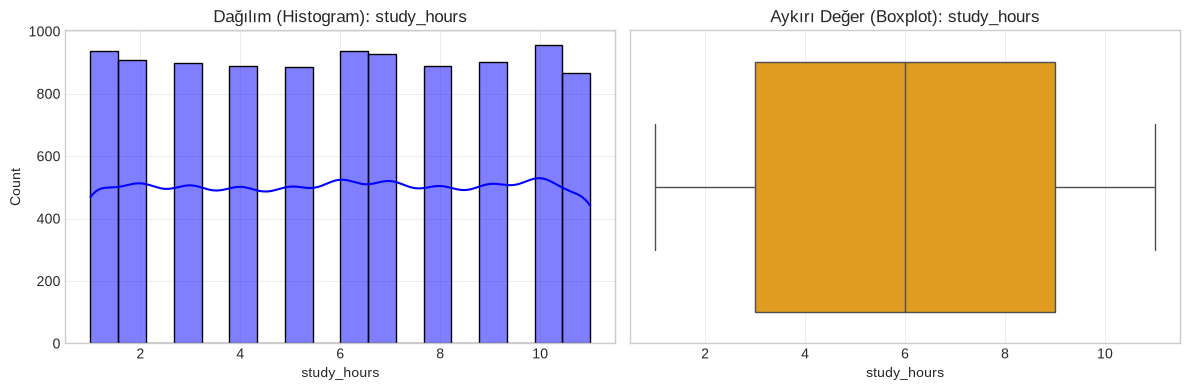

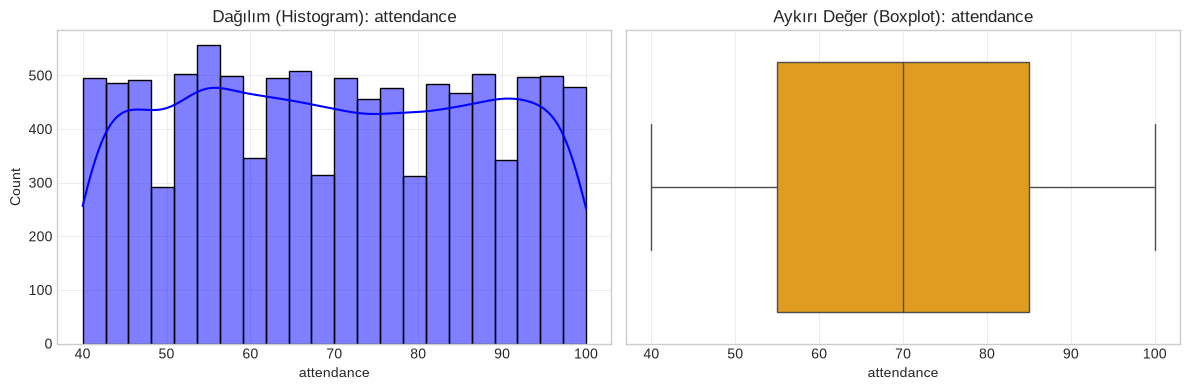

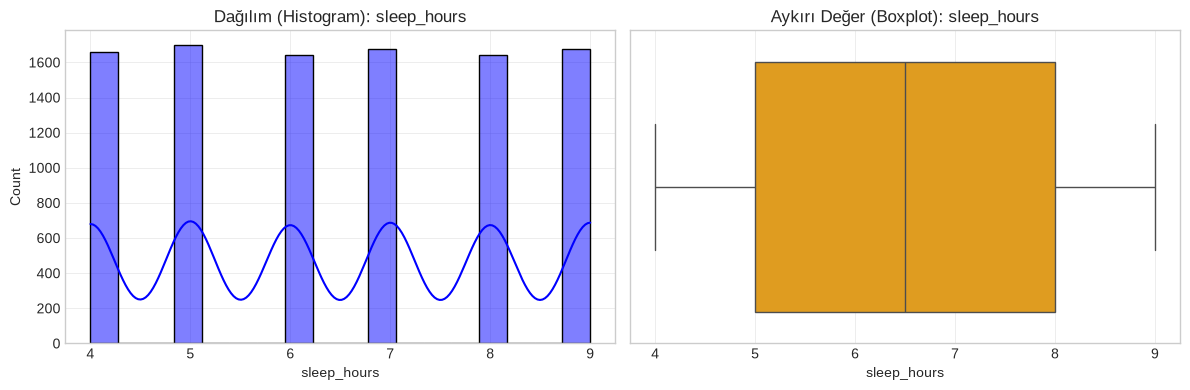

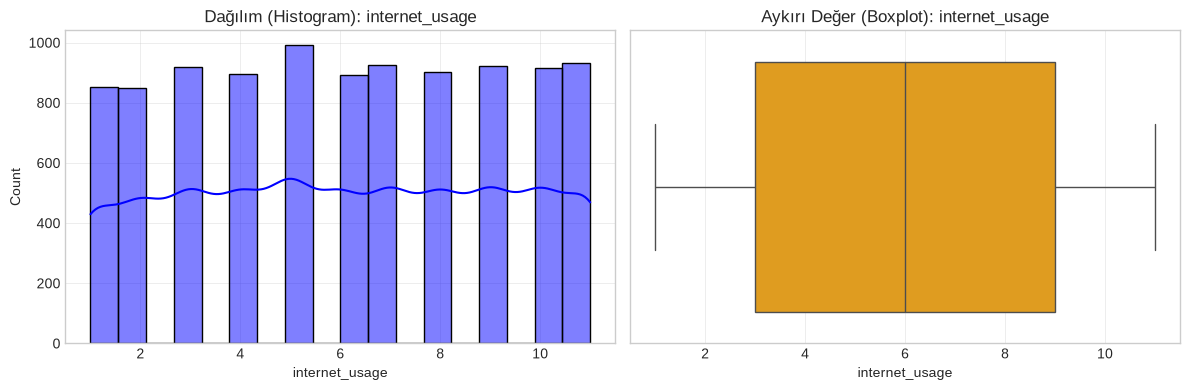

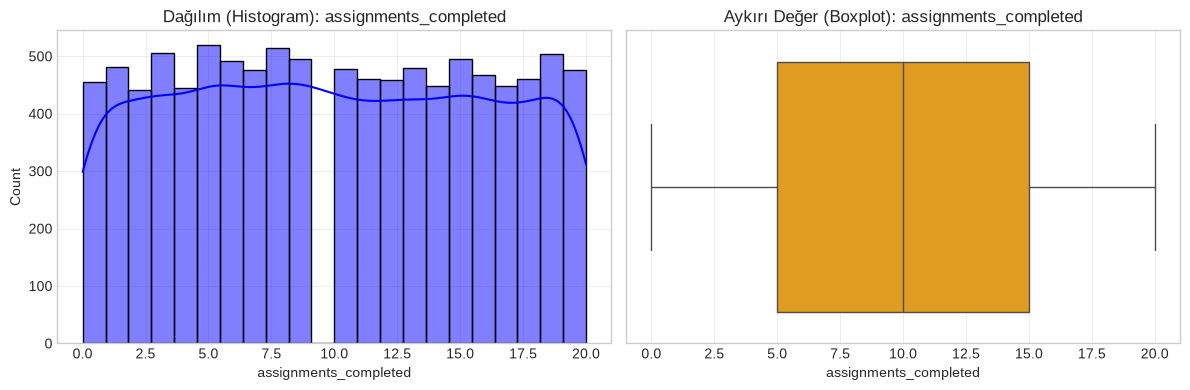

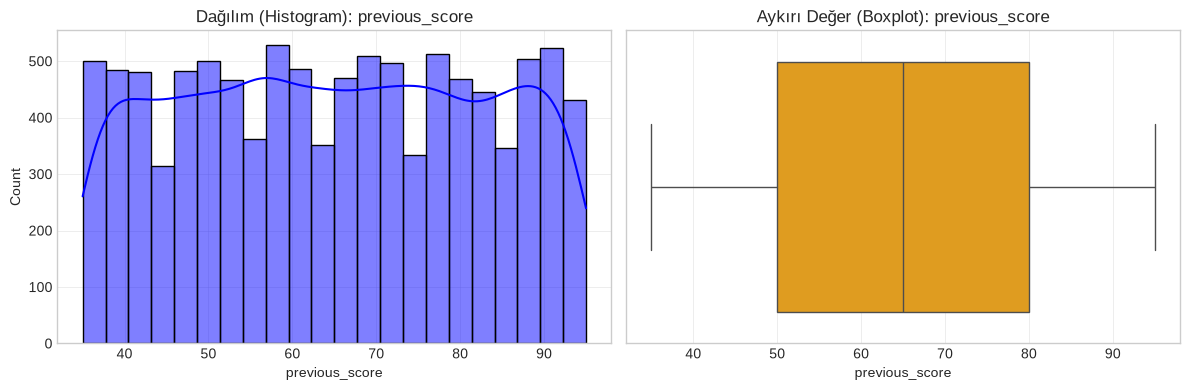

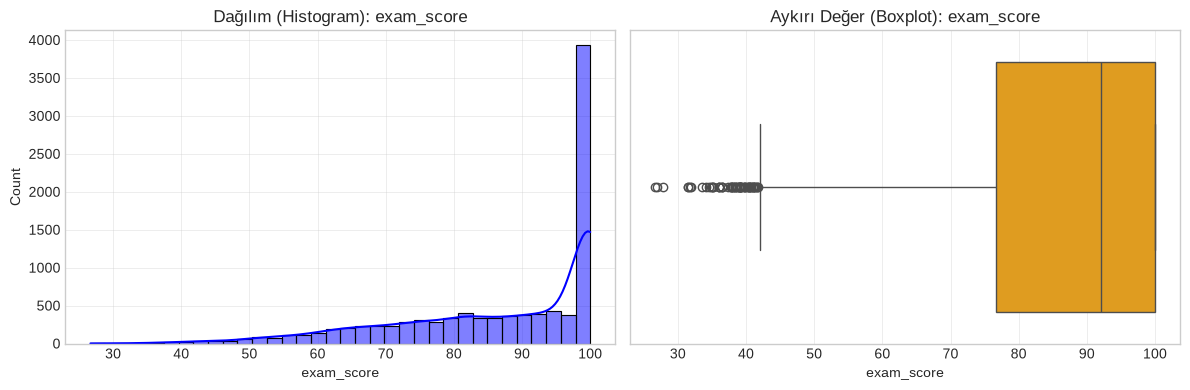

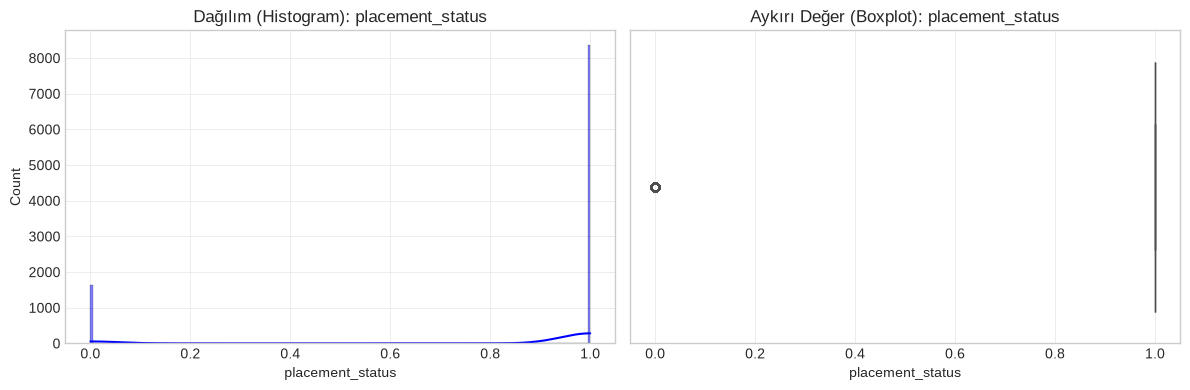

In [5]:
# Sayısal dağılımları çiz
print("--- Sayısal Sütun Dağılımları ---")
plot_statistical_distributions(df, numeric_cols)

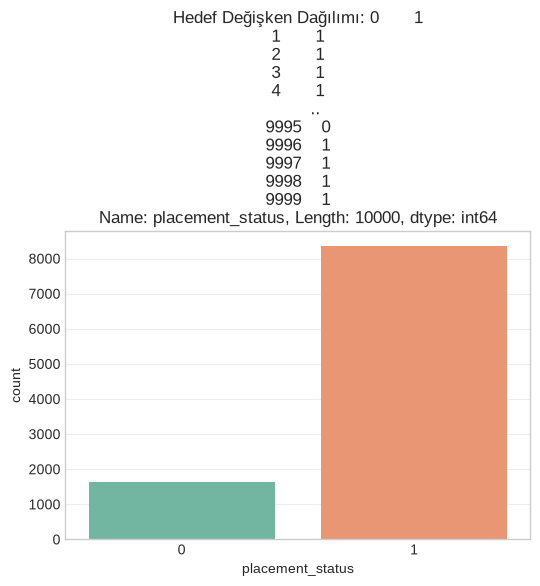

In [6]:
# --- 3. Hedef Değişken (Target) Dağılımı ---
# Hedef sütunu ayarlama
target_column = df["placement_status"]
plot_target_distribution(df, target_column)

=== Target ile Korelasyon Sıralaması ===
exam_score               0.792392
study_hours              0.400934
assignments_completed    0.280138
previous_score           0.232693
attendance               0.176738
sleep_hours              0.110578
internet_usage          -0.110233
Name: placement_status, dtype: float64
----------------------------------------


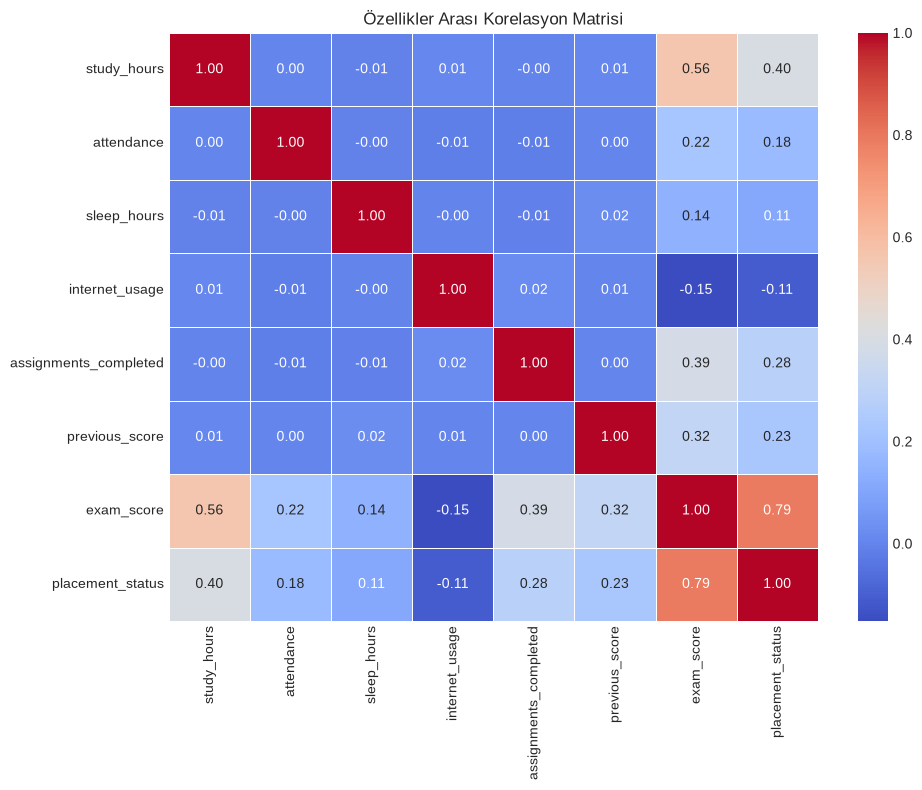

⚠️ Yüksek korelasyonlu (çakışan) özellikler: []


In [7]:
# --- 4. Coefficient ve Correlation Eğrileri + Target İlişkisi ---
target_corr, to_drop = analyze_feature_correlations(df, target_col="placement_status")

In [8]:
# --- 5. Verinin Eğitim ve Test Olarak Ayrılması ---
X = df.drop(columns=["placement_status"])
y = df["placement_status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Veri Bölündü -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Veri Bölündü -> Train: (8000, 7), Test: (2000, 7)


In [9]:
# --- 6. Outlier Değerleri Belirleme ---
X_train_clipped, X_test_clipped, outlier_summary = apply_iqr_clipping(X_train, X_test, numeric_cols)

=== Aykırı Değer (Outlier) Sayıları ===
🔸 exam_score: 48 adet aykırı değer bulundu.
8. IQR Clipping İşlemi Tamamlandı (Faktör: 1.5).


In [10]:
# --- 7. Correlation Filtresi (Clipping Sonrasında) ---
X_train_corr, X_test_corr = correlation_filter(
    X_train_clipped, X_test_clipped, corr_threshold=0.95
)

9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: 7


In [11]:
# --- Sabit (Constant) Sütunları Temizleme ---
constant_cols = [col for col in X_train_corr.columns if X_train_corr[col].nunique() <= 1]

if constant_cols:
    print(f"Sabit sütunlar tespit edildi ve çıkarılıyor: {constant_cols}")
    X_train_corr = X_train_corr.drop(columns=constant_cols)
    X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
    print("Sabit sütun bulunamadı.")

Sabit sütun bulunamadı.


In [12]:
# --- 8. Öznitelik Seçimi (Feature Selection) ---
selected_features = select_best_features_anova(X_train_corr,y_train)
X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== En İyi 5 Özellik (ANOVA / SelectKBest) ===
                 Feature         Score
6             exam_score  13688.119827
0            study_hours   1522.569175
4  assignments_completed    744.153195
5         previous_score    449.479781
1             attendance    238.405730


In [13]:
# Hepsini tek bir pakette topla
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
# Tek dosyaya kaydet
joblib.dump(bundle, "../backend/models/student/student_data_bundle.pkl")
print(
    "İşlenmiş bankloan veri setleri başarıyla backend/models/student/"
    " klasörüne kaydedildi!"
)

İşlenmiş bankloan veri setleri başarıyla backend/models/student/ klasörüne kaydedildi!
